# Low Fidelity Neural Network
Neural Network which uses LF dataset and exploits the Low fidelity component of the MF model. The NN is tested also on the HF test set  

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from keras.utils import custom_object_scope
from keras.initializers import glorot_uniform
from keras.models import load_model, save_model
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3 import (
    getModel,
    kCrossVal,
    transfBestparam,
    kCrossValSingle,
    import_data, normalization
)
from time import perf_counter
import pandas
import os
import keras
import tensorflow as tf

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Data Preparation

In [3]:
file_path_LF = "../DATA/reaction_diffusion_LF_46_d75.mat"
(reaction_LF_test, U_LF_test) = import_data(file_path_LF)

NepoLF = 7000  # number of epochs for second NN: NN_HF


reaction_LF_test = normalization(reaction_LF_test)
U_LF_test = U_LF_test[:, -1, 12,12]
U_LF_test=normalization(U_LF_test)
reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
U_LF_test_original=U_LF_test

In [4]:
# randomization
Nlf = 200

# NOISE
noise_stddev2 = 0.02       # value?
noise2 = np.random.normal(0, noise_stddev2, U_LF_test.shape)
noise_stddev3 = 0.01       # value?
noise3 = np.random.normal(0, noise_stddev3, U_LF_test.shape)
U_LF_noise2 = U_LF_test + noise2
U_LF_noise3 = U_LF_test + noise3
noise_stddev4 = 0.02       # value?
noise4 = np.random.normal(0, noise_stddev4, U_LF_test.shape)
noise_stddev5 = 0.01       # value?
noise5 = np.random.normal(0, noise_stddev5, U_LF_test.shape)
U_LF_noise4 = U_LF_test + noise4
U_LF_noise5 = U_LF_test + noise5
noise_stddev6 = 0.02       # value?
noise6 = np.random.normal(0, noise_stddev6, U_LF_test.shape)
U_LF_noise6 = U_LF_test + noise6
noise_stddev7 = 0.01       # value?
noise7 = np.random.normal(0, noise_stddev7, U_LF_test.shape)
U_LF_noise7 = U_LF_test + noise7

U_LF_test = np.concatenate((U_LF_test, U_LF_noise2,U_LF_noise3,U_LF_noise4,U_LF_noise5,U_LF_noise6,U_LF_noise7),axis=0)

noise_stddev2 = 0.01       # value?
noise2 = np.random.normal(0, noise_stddev2, reaction_LF_test.shape)
noise_stddev3 = 0.005       # value?
noise3 = np.random.normal(0, noise_stddev3, reaction_LF_test.shape)
reaction_LF_noise2 = reaction_LF_test + noise2
reaction_LF_noise3 = reaction_LF_test + noise3
noise_stddev4 = 0.01       # value?
noise4 = np.random.normal(0, noise_stddev4, reaction_LF_test.shape)
noise_stddev5 = 0.005       # value?
noise5 = np.random.normal(0, noise_stddev5, reaction_LF_test.shape)
reaction_LF_noise4 = reaction_LF_test + noise4
reaction_LF_noise5 = reaction_LF_test + noise5
noise_stddev6 = 0.005       # value?
noise6 = np.random.normal(0, noise_stddev6, reaction_LF_test.shape)
reaction_LF_noise6 = reaction_LF_test + noise6
noise_stddev7 = 0.01       # value?
noise7 = np.random.normal(0, noise_stddev7, reaction_LF_test.shape)
reaction_LF_noise7 = reaction_LF_test + noise7

reaction_LF_test = np.concatenate((reaction_LF_test, reaction_LF_noise2,reaction_LF_noise3,reaction_LF_noise4,reaction_LF_noise5,reaction_LF_noise6,reaction_LF_noise7))



permutation = np.random.permutation(len(reaction_LF_test))

reaction_LF = reaction_LF_test[permutation][0:Nlf]
U_LF = U_LF_test[permutation][0:Nlf]

reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]



# Low Fidelity Neural Network
## Low fidelity data

In [5]:
start = perf_counter()

#reaction_final = np.vstack(
#    (reaction_LF)
#)  

name="LF"
K.clear_session()
best_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
print(best_params)


{'lr': 0.0255, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}


In [6]:
# start = perf_counter()

# reaction_final = np.vstack(
#     (reaction_LF)
# )  

# ##########################       NN_LF     ##########################
# ####################    HYPERPARAMETER OPTIMIZATION    #######################
# MAX_EVAL = 15
# name = "LF"
# K.clear_session()
# bayes_trials = Trials()
# opt_list = ["Adam", "Adamax"]
# kernel_list = ["uniform", "glorot_uniform"]
# aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
# space = {
#     "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
#     "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(100)),
#     "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
#     "kernel_init": hp.choice("kernel_init", kernel_list),
#     "opt": hp.choice("opt", opt_list),
# }


# def objective(params):
#     K.clear_session()
#     CVres = kCrossValSingle(Nlf, NepoLF, reaction_final, U_LF, params, name)
#     return {"loss": CVres, "params": params, "status": STATUS_OK}


# best_params = fmin(
#     fn=objective,
#     space=space,
#     algo=tpe.suggest,
#     max_evals=MAX_EVAL,
#     trials=bayes_trials,
# )

# transfBestparam(best_params, aux_dic)
# print(best_params)

# ####################    NN training and PREDICTION    #######################
start2 = perf_counter()
finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters
hist = finalModel.fit(
    reaction_LF,
    U_LF,
    validation_data=(reaction_LF_test_original, U_LF_test_original),
    epochs=NepoLF,
    batch_size=Nlf,
    verbose=0,
    validation_freq=20,
)

ULF = finalModel.predict(reaction_LF_test_original)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nLF Model:")

elapsed2 = stop - start2
print("Elapsed time: ", elapsed2)
print("\nLF Model:")

test_mse = np.mean(np.square(U_LF_test_original - ULF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_LF = 1 - np.sum(np.square(U_LF_test_original - ULF[:, 0])) / np.sum(
    np.square(U_LF_test_original - np.mean(U_LF_test_original))
)
print(f"R^2: {r2_LF}")


2/2 [==============================] - 0s 16ms/step
Elapsed time:  59.318833400000585

LF Model:
Elapsed time:  59.285032000014326

LF Model:
Test MSE: 0.002417694295998903
R^2: 0.9803587658879481


## High Fidelity data

In [7]:
####################    NN training and PREDICTION HF   #######################
# start2 = perf_counter()
finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters

file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
#U_HF_test = U_HF_test[
#    :, -1, int(np.shape(U_HF_test)[2] / 2), int(np.shape(U_HF_test)[3] / 2)
#]
U_HF_test = U_HF_test[
    :, -1, 44,44
]

reaction_HF_test = normalization(reaction_HF_test)
reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

U_HF_test = normalization(U_HF_test)
U_HF_test_original=U_HF_test


noise_stddev2 = 0.01       # value?
noise2 = np.random.normal(0, noise_stddev2, U_HF_test.shape[0])
noise_stddev3 = 0.005       # value?
noise3 = np.random.normal(0, noise_stddev3, U_HF_test.shape[0])
U_HF_noise2 = U_HF_test + noise2
U_HF_noise3 = U_HF_test + noise3

noise_stddev4 = 0.02       # value?
noise4 = np.random.normal(0, noise_stddev4, U_HF_test.shape[0])
noise_stddev5 = 0.005       # value?
noise5 = np.random.normal(0, noise_stddev5, U_HF_test.shape[0])
U_HF_noise4 = U_HF_test + noise4
U_HF_noise5 = U_HF_test + noise5



U_HF_test = np.concatenate((U_HF_test, U_HF_noise2,U_HF_noise3,U_HF_noise4,U_HF_noise5),axis=0)

noise_stddev2 = 0.005       # value?
noise2 = np.random.normal(0, noise_stddev2, reaction_HF_test.shape)
noise_stddev3 = 0.003       # value?
noise3 = np.random.normal(0, noise_stddev3, reaction_HF_test.shape)
reaction_HF_noise2 = reaction_HF_test + noise2
reaction_HF_noise3 = reaction_HF_test + noise3

noise_stddev4 = 0.01       # value?
noise4 = np.random.normal(0, noise_stddev4, reaction_HF_test.shape)
noise_stddev5 = 0.003       # value?
noise5 = np.random.normal(0, noise_stddev5, reaction_HF_test.shape)
reaction_HF_noise4 = reaction_HF_test + noise4
reaction_HF_noise5 = reaction_HF_test + noise5

reaction_HF_test = np.concatenate((reaction_HF_test, reaction_HF_noise2,reaction_HF_noise3,reaction_HF_noise4,reaction_HF_noise5))


reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]



hist = finalModel.fit(
    reaction_LF,
    U_LF,
    validation_data=(reaction_HF_test_original, U_HF_test_original),
    epochs=NepoLF,
    batch_size=Nlf,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_HF_test_original)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Data")
print("\nLF Model:")

elapsed2 = stop - start2
print("Elapsed time: ", elapsed2)
print("\nLF Model:")

test_mse_HF = np.mean(np.square(U_HF_test_original - UHF[:, 0]))
print(f"Test MSE: {test_mse_HF}")

r2_HF = 1 - np.sum(np.square(U_HF_test_original - UHF[:, 0])) / np.sum(
    np.square(U_HF_test_original - np.mean(U_HF_test_original))
)
print(f"R^2: {r2_HF}")


2/2 [==============================] - 0s 16ms/step
Elapsed time:  155.76459479998448

HF Data

LF Model:
Elapsed time:  155.73079339999822

LF Model:
Test MSE: 0.16303453884653174
R^2: -0.440249875236173


# Plot

2/2 [==============================] - 0s 4ms/step


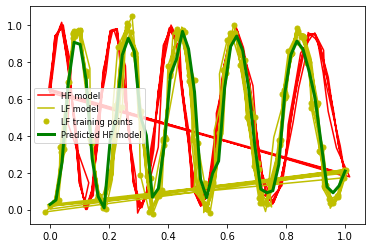

In [11]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model")
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(reaction_LF_test[:,0], U_LF_test, "y-", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF[:,0],
    U_LF,
    "yo",
    markersize=5,
    label="LF training points",
)
plt.plot(
    reaction_HF_test_original[:,0],
    finalModel.predict(reaction_HF_test_original),
    "g-",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

#########################     SAVE the OUTPUT      ##########################
os.makedirs("NNLF_LF200_7000_noise_fourier")

R2_HF = pandas.DataFrame({"R2_HF": [r2_HF]})
R2_LF = pandas.DataFrame({"R2_LF": [r2_LF]})
MSE_test_LF = pandas.DataFrame({"MSE_test_LF": [test_mse]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [test_mse_HF]})


R2_LF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/r2_HF.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
MSE_test_HF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
MSE_test_LF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
